# Introduction to Time Series


## Prerequisites:
- Stochastic Process
- Basic ML Concepts


## Learning Objectives:
- Understand the concept of time-series and its difference from conventional machine learning problems.
- Understand trends and seasonal patterns observed in time-series.
- Understand the idea of a statistical model for time-series. 


A time series is a collection of data points or observations indexed in the order of time. We can call any sequence of experimental observations taken at equally spaced timestamps a time series. Thus, it's a sequence of discrete-time data. The spacing between any two timestamps in the series can be as small as that in electrocardiogram (80-100 ms) or voice signals (22.6 $\mu$s for 441.kHz voice recorders) to as large as monthly, quarterly, half-yearly, or yearly sales data. A time-series $X$ of length $T + 1$ can be represented as $X = \{ x_t \} _{t = 0 }^ T$ where $x_t$ is the observation or value at timestamp $t$ and $T$ is the time-stamp for the last observation. Figure 1 shows the time ordering of a time-series with 14 observations. 

<center>


<p>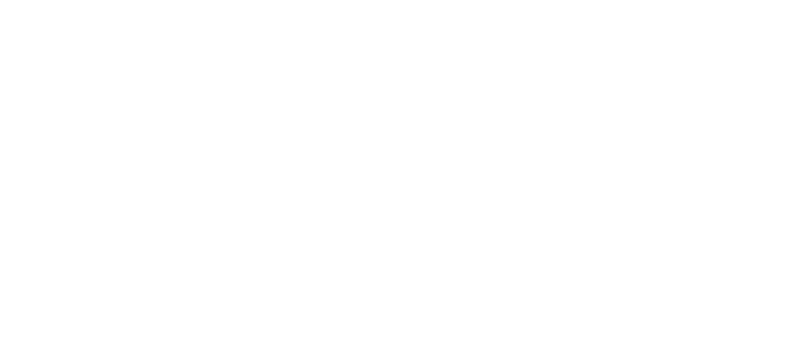</p>

Figure 1: Time Series
</center>

Given a time-series $ X $, as defined before, the interest will be to extrapolate the values at future timestamps by studying and capturing the time-series' nature. As shown in Figure 2, we need to forecast the future timestamps' values, shown by green dots, given the observed data in red dots. This extrapolation is called time series forecasting. For business, it adds significant economic value. A proper economic forecast aids a company in preparing its production, technical support, workforce, and so on for its growth. 

<center>


<p>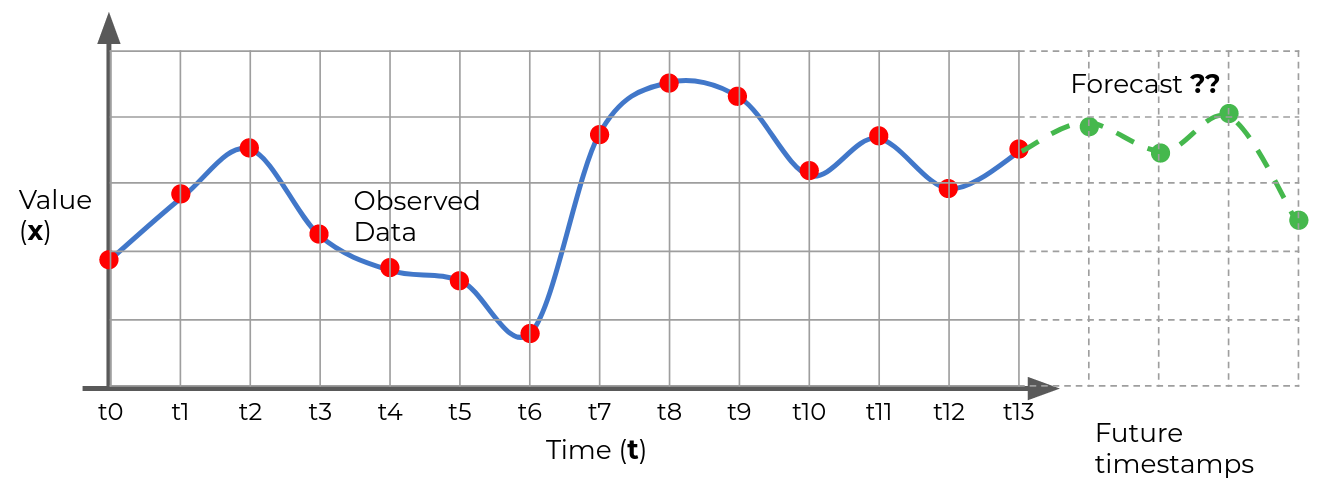</p>

Figure 2: Time Series Forecasting
</center>

The presumption that any two data points are independent and identically distributed ($iid$) is one of the core assumptions for conventional machine learning problems. However, there's an apparent correlation between the neighboring data points in the case of a time-series. It's an intrinsic property for almost every time series. The time ordering is thus vital for the time series problems. Thus, we can't directly apply many conventional machine learning techniques for time series problems. Time series forecasting leads to a new and unique family of statistical modeling and inference techniques, commonly referred to as **Time Series Analysis (TSA)**. 

TSA has many applications, ranging from daily life use cases to business usages. In medicine, tracing the blood pressure measurements over time can be useful in evaluating the effects of drugs and can be used to treat hypertension. Similarly, many economic variables, like sales, stock price, employee turnover rate, etc., can be formulated as a time series problem. Likewise, TSA can be applied in weather forecasting, rainfall estimation, etc. Different fields, like control engineering, communications engineering, signal processing, etc., also find TSA usage.


## Patterns in Time Series

Now that we know what a time series is, we can describe it by some distinguishing patterns viz: trend and seasonality. We will discuss these two terms below. 


### Trend

When there is a long-term increase or decrease in the data, we say it has a trend. The trend does not have to be necessarily linear. We'll see linear as well as exponential trends in future chapters. Figure 3 (left) shows the linear trend pattern.

<center>


<p>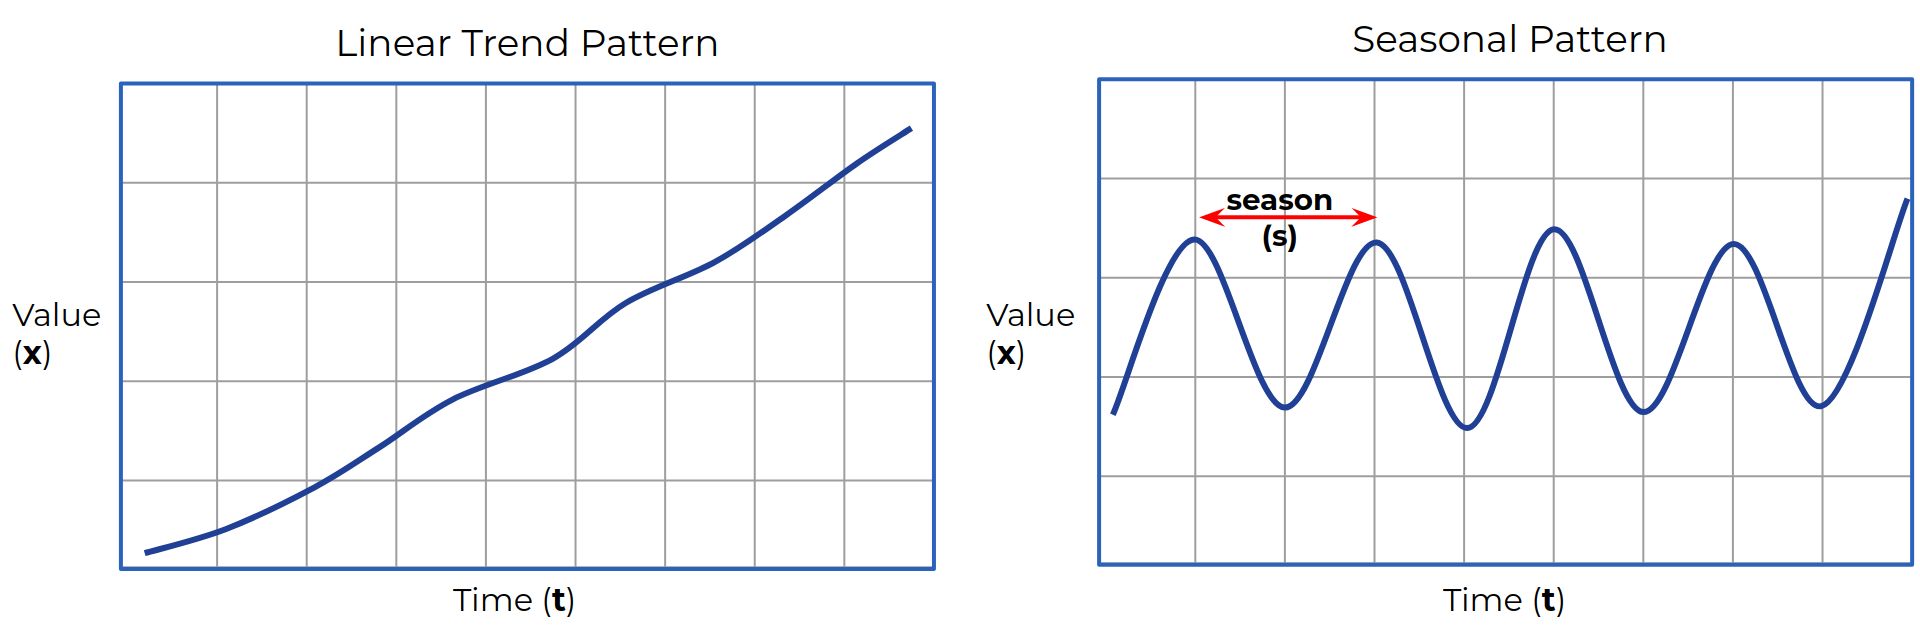</p>

Figure 3: Linear Trend (left) and Seasonal Patterns (right)
</center>



### Seasonality

Seasonality is the repetition of a certain pattern seen over time, which is periodic and has a fixed frequency. Figure 3 (right) shows the seasonal pattern. An example of seasonal data is the sales data for warm clothes. The data is seasonal since the sales go high every winter and are low in summer. We call the length of the period over which the pattern repeats as a season (not to be confused with climatic season). For example, for monthly sales data of warm clothes, the seasonal pattern repeats every 12 timestamps. Hence, its season is 12.  

When a significant amount of trend and seasonality are not present in the time series, we call the time series stationary. The formal definition of stationarity is a bit complicated. We'll explore this topic in future chapters.


## Time Series Examples

In the above sections, we defined time series, discussed some common patterns observed in time series, and learned that no $iid$ assumption differentiates it from conventional ML. Now, let's explore some real-world examples of time series. We'll use `matplotlib` to generate plots for these time series. Next, we'll import the libraries required for this reading material. 


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Next, we'll define a `plot_series` function to plot the graphs for the given time series using `matplotlib`. 


In [ ]:
font = {'size' : 12}
matplotlib.rc('font', **font)

def plot_series(X, title='Time Series Plot', y_label='Value of X', figsize=(16, 6)):
    """ Plots the time series data X.

    Args:
        X (np.array): Time-series data
        title (str): Title for the figure
        y_label (str): y-label for the figure
        figsize (tuple): Size of figure
        
    """
    
    fig = plt.figure(figsize=figsize)
    if type(X) is np.array:
        plt.plot(X, linewidth=3)
    else:
        X.plot(linewidth=3)
        
    plt.title(title, fontsize=15)
    plt.xlabel('Date', fontsize=13)
    plt.ylabel(y_label, fontsize=13)
    plt.legend([y_label])
    plt.grid()
    plt.show()

#### Daily total female births in California, 1959

[[source_link](https://www.kaggle.com/dougcresswell/daily-total-female-births-in-california-1959)]

- This data consists of the total number of female births recorded in California, USA, during 1959. 


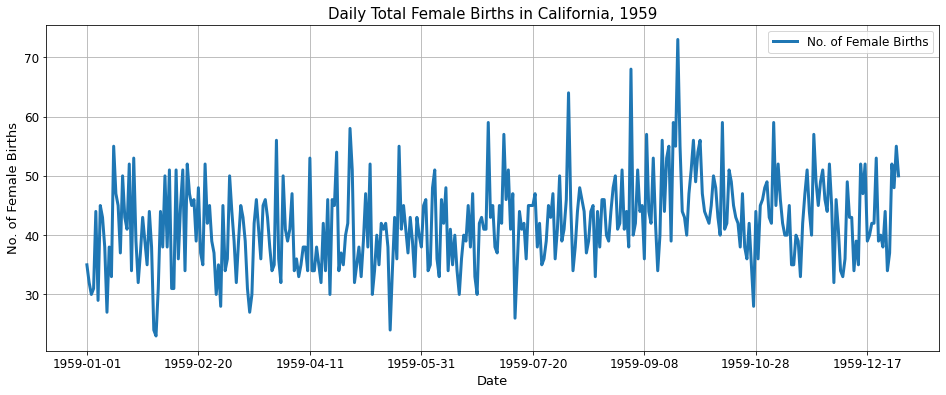

In [ ]:
df_fb = pd.read_csv("https://storage.googleapis.com/codehub-data/1-lv2-11-1-daily-total-female-births-CA.csv")
df_fb.set_index(df_fb.date, inplace=True)

plot_series(
    df_fb['births'], 
    title='Daily Total Female Births in California, 1959',
    y_label='No. of Female Births'
)

This data doesn't have a significant trend and seasonality. Such data is said to be stationary. 



#### Google Stock 
[[source_link](https://finance.yahoo.com/quote/GOOG/history?p=GOOG
)]

- This is the daily stock price for Google from 2004-08-19 onwards. We'll plot the daily high stock values in the following graph. 


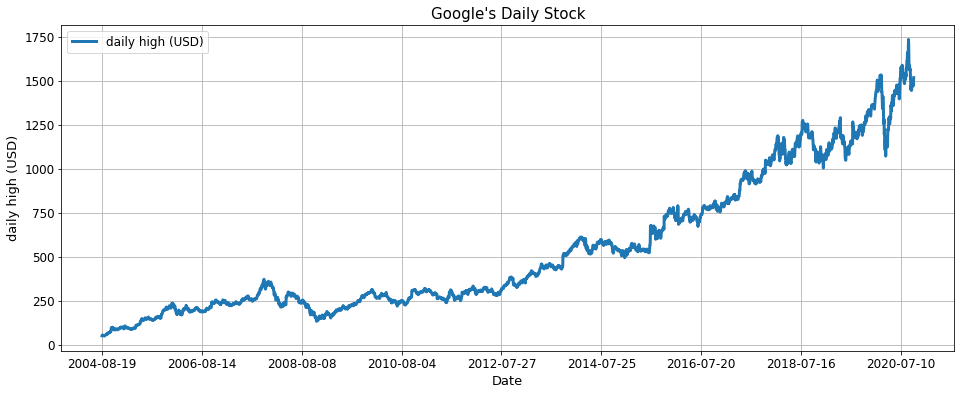

In [ ]:
df_gs = pd.read_csv("https://storage.googleapis.com/codehub-data/1-lv2-11-1-GOOG.csv")
df_gs.set_index(df_gs.Date, inplace=True)

plot_series(
    df_gs['High'], 
    title="Google's Daily Stock",
    y_label='daily high (USD)'
)

The values have an increasing trend. But, we cannot observe significant seasonality in this data.


#### Temperature Data
[[source_link](https://www.ncdc.noaa.gov/cag/national/time-series)]

- The dataset consists of the monthly average temperature of Massachusetts state of America from 1985 to 2019. Let's plot the data. 


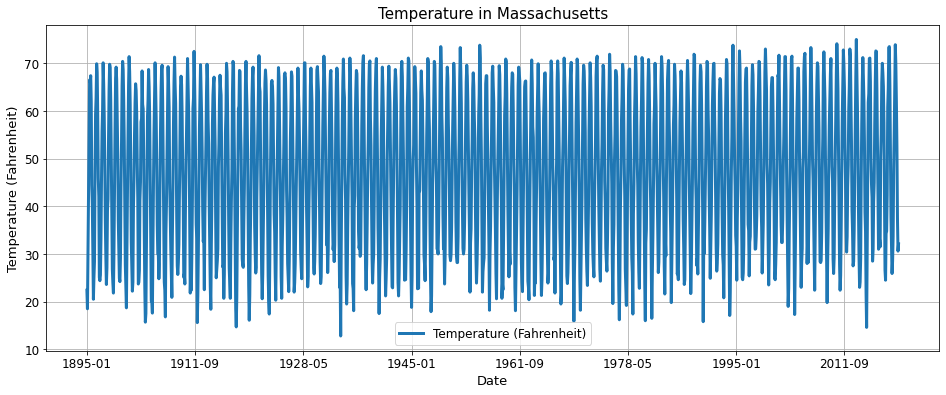

In [ ]:
df_td = pd.read_csv("https://storage.googleapis.com/codehub-data/1-lv2-11-1-Temperature.csv")
df_td.set_index(df_td.Date, inplace=True)

plot_series(
    df_td['Value'], 
    title='Temperature in Massachusetts',
    y_label='Temperature (Fahrenheit)'
)

The temperature is affected by the seasons: hot in summer and cold in winter. And this pattern repeats every year. So, we can expect the data has a seasonal pattern in this data. We can get some sense of seasonality from the above plot. The data seems to be fluctuating around an average line. Let's see how the data changes over months for all the given years.


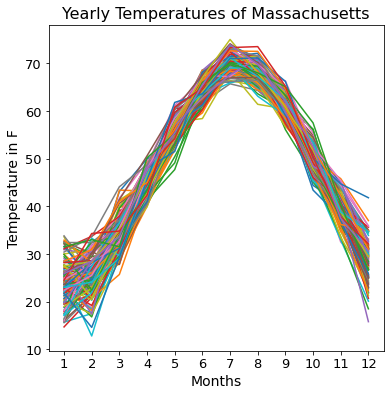

In [ ]:
def plot_monthwise(pivot, title, ylabel):    
    pivot.plot(figsize=(6, 6), fontsize=13)
    plt.title(title, fontsize=16)
    plt.ylabel(ylabel, fontsize=14)
    plt.xlabel('Months', fontsize=14)
    plt.xticks(range(1, 13))
    plt.legend().remove()
    plt.plot()

index = pd.DatetimeIndex(df_td.index) 
pivot = pd.pivot_table(df_td, values='Value', index=index.month, columns=index.year)

plot_monthwise(pivot, title='Yearly Temperatures of Massachusetts', 
               ylabel='Temperature in F')

The above plot shows the month-wise temperature for all the years. Different color represents temperatures for different years. The temperature seems to be low in December(12), January (1) and February(2), whereas high in June (6), July (7). Observing the plot, we can infer that the data is seasonal with a period of 12. 



#### Air Passengers 
[[source_link](https://www.kaggle.com/abhishekmamidi/air-passengers)]

This data consists of the number of air passengers from 1949 to 1960 recorded for each month. Thus, there are 12 * 12 = 144 data points in the data. 


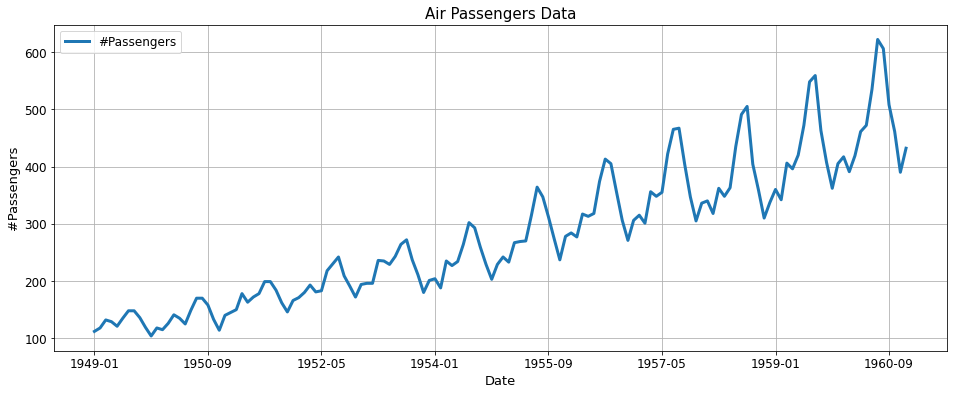

In [ ]:
df_ap = pd.read_csv("https://storage.googleapis.com/codehub-data/1-lv2-11-1-AirPassengers.csv")
df_ap.set_index(df_ap.Month, inplace=True)

plot_series(
    df_ap['#Passengers'], 
    title='Air Passengers Data',
    y_label='#Passengers'
)

Let's plot the data. The data seems to have an upward trend inferring the number of air passengers has increased over the years. The variance of the data seems to be increasing with time. And, also a pattern of increase and decrease seems to be repeating over the years. Let's plot the month-wise plot to see if the values are repeating with a period of 12.  


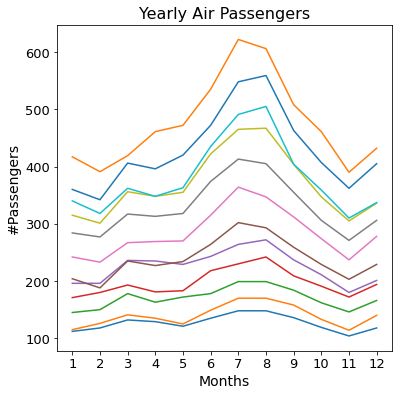

In [ ]:
index = pd.DatetimeIndex(df_ap.index) 
pivot = pd.pivot_table(df_ap, values='#Passengers', index=index.month, columns=index.year)

plot_monthwise(pivot, title='Yearly Air Passengers', 
               ylabel='#Passengers')

The number of air passengers seems to be high during June-July (months 7 and 8) and less in other months for each year. However, we cannot notice the strong seasonal pattern as observed in temperature data before. The reason is that the temperature data lacked a trend, and the variation was constant. However, here the data has a trend, and also, the variation is increasing with time. To mitigate this, let's divide the data for each year by the mean for the corresponding year and plot the month-wise plot. 


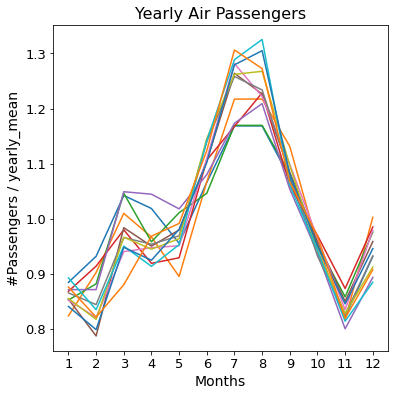

In [ ]:
pivot_normalized = pivot / pivot.mean()

plot_monthwise(pivot_normalized, title='Yearly Air Passengers', 
               ylabel='#Passengers / yearly_mean')

Now, we can see more strong seasonal pattern in the data.


## Statistical Time Series Model

Now, you've learned about time series, different real-world time series data. And, we talked about time series analysis too. Let's formulate a framework to stochastically model the data generation process and the time series data, which we can use to make forecasts for future timestamps. This stochastic model is fundamental to several TSA models like Autoregressive, Moving Average, and so on, which we'll study in the future chapters. 

Like all ML data, the time series doesn't have a deterministic form. Every measurement is prone to different noise levels introduced in the data generating process, be it due to environmental factors or the generator itself. To model the intrinsic stochastic nature of time series and give it a statistical formulation, we assume that the underlying data generating process is a stochastic process. The stochastic process is the collection of random variables $X_0, X_1, X_2, X_3, ...$ indexed over time. On that note, the time series is the collection of the observed values of the stochastic process. We also call the time series a realization of the process. If we represent the observed value of the variable $X_t$ by $x_t$, then the time series $X$ of length $T + 1$ is defined as $X = \{X_t = x_t\}_{t=0}^T$.



## Key Takeaways

1. A time series is a collection of data points or observations indexed in the order of time.

2. $iid$ assumption is not valid for time-series. Hence many conventional ML techniques cannot be applied, suggesting new statistical models need to be built for time series analysis.  

3. The long-term increase or decrease in data is termed a trend, and the periodic repetition in the pattern is called seasonality. 

4. Statistical time series model models a time-series data generating process as the collection of random variables $X_t$ and time series as the sequence of the realizations $x_t$.


## References

- Shumway R., Stoffer D. (2016) Time Series Analysis and Its Applications: With R Examples, 4th edition, Springer
    * Check chapter 1.2 in page 8 for more information on statistical time series models.
